# 5. Evaluation and Interpretability 🤔

In the previous notebook we learnt how to train a k-NN classifier for different tasks:
* Movie review classification (is the review positive or negative?)
* Instrument family classification (is the recording from a string, brass, keyboard or wind instrument?)
* Image classification (is this an image of an aeroplane or an automobile?)

For optimising our model, we relied on evaluating its **accuracy**, that is, how many times the prediction of the model was the same as the expected output. However, **accuracy** is only one way to measure how well a model performs. Sometimes, a model can have a high accuracy overall but still make important mistakes. Relying solely on accuracy could cause us to **misunderstand how well the model works**.

In this notebook, we will go beyond accuracy and explore **other evaluation metrics** that help us better understand a model's performance, such as:  
- **Precision**
- **Recall**  
- **F1 Score**

We'll also explore another ways of **interpreting a model's predictions**, a **confusion matrix**.

These tools give us a more detailed view of **what kinds of predictions the model is getting right or wrong**.  





## How good is our model?

We've been using accuracy as the metric to optimise in our models. We have adjusted hyperparameters to achieve the highest accuracy possible on the validation set, but, how do we know if the model is good enough? What can we use as a reference for this?

### Evaluate Against a Baseline 📊

When we train a machine learning model, it's important that we evaluate it with relation to at least one **baseline**. A baseline could be *another model*, or a simpler method that does not use machine learning. A usual baseline is to consider **chance performance**, that, is, a system that randomly predicts one of the possible outputs.

Let's revisit our movie review classifier:

You can simply run the following cel without worrying too much, as it builds functions with what we did in previous notebooks. We'll call the newly defined `load_and_prepare_imdb_dataset` and `train_knn_model` functions in the code.

> It's worth clarifying that when we apply standardisation for the test dataset we use the mean and standard deviation of the train set! If we think about it, as the test data is unseen data, we shouldn't treat that set as a group we already know. If our system is seeing a new example, we don't know what other examples are coming after that one!

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier

def load_and_prepare_imdb_dataset():
    # load data
    imdb_dataset = pd.read_csv("features_and_labels_text.csv")
    imdb_dataset.head()

    # Remove rows where all values are 0
    y_text = imdb_dataset["label"]
    X_text = imdb_dataset.drop(columns=["label"])
    mask = (X_text != 0).any(axis=1)
    X_text = X_text[mask]
    y_text = y_text[mask]

    # Split dataset
    X_text_train, X_text_test, y_text_train, y_text_test = train_test_split(X_text, y_text, test_size=0.30, random_state=0)
    return X_text_train, X_text_test, y_text_train, y_text_test


def train_knn_model(k_neighbors, X_train, y_train):
    # Set up k-fold with 5 splits
    n_splits = 5
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    # initialize the model
    k_text=k_neighbors
    model = KNeighborsClassifier(n_neighbors=k_text)

    accuracies = []
    # iterate over each fold
    for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X_train)):
        # train the model with the training indices for this fold
        model.fit(X_train.iloc[train_idx], y_train.iloc[train_idx])
        # predict on the validation set for this fold
        predictions = model.predict(X_train.iloc[val_idx])
        # compute accuracy for this fold
        accuracy = accuracy_score(y_train.iloc[val_idx], predictions)
        # store the accuracy for this fold
        accuracies.append(accuracy)

    return model, np.mean(accuracies)

Let's recover our model for classifying movie reviews.

In [14]:
X_text_train, X_text_test, y_text_train, y_text_test = load_and_prepare_imdb_dataset()
k_neighbors_text = 141
knn_model_text, avg_accuracy_text = train_knn_model(k_neighbors_text, X_text_train, y_text_train)

How does our model perform on the test data?

In [9]:
y_text_pred = knn_model_text.predict(X_text_test)
test_accuracy_text = accuracy_score(y_text_test, y_text_pred)
print(f"Average Cross-Validation Accuracy: {avg_accuracy_text:.4f}")
print(f"Test Accuracy: {test_accuracy_text:.4f}")

Average Cross-Validation Accuracy: 0.6626
Test Accuracy: 0.6619


Great, we mantained our performance on the test set!

But, how good is that? Let's compare that to chance performance.

In [20]:
# what are the possible outputs?
possible_outputs_text = set(y_text_test.unique())

def random_output(possible_outputs, y_test):
    y_random = []
    for i in range(len(y_test)):
        # randomly select an output from the possible outputs
        y_random.append(np.random.choice(list(possible_outputs)))
    return y_random

# what is the accuracy for the random baseline?
y_random_text = random_output(possible_outputs_text, y_text_test)
random_accuracy_text = accuracy_score(y_text_test, y_random_text)
print(f"Random Baseline Accuracy: {random_accuracy_text:.4f}")

Random Baseline Accuracy: 0.5049


The baseline has a 50% accuracy. This means that our simple machine learning model's performance is 1.32 times better than the baseline.

What about our instrument family classifier? Let's retrieve the model.

In [ ]:
def load_and_prepare_tinysol_dataset():
    # Load data
    tinysol_dataset = pd.read_csv("features_and_labels_audio.csv")
    tinysol_dataset.head()

    # Remove rows where all values are 0
    y_audio = tinysol_dataset["Family"]
    X_audio = tinysol_dataset.drop(columns=["Family"])

    # Split dataset
    X_audio_train, X_audio_test, y_audio_train, y_audio_test = train_test_split(X_audio, y_audio, test_size=0.30, random_state=0)
    # Standardise data
    X_audio_train_standardised = (X_audio_train - X_audio_train.mean()) / X_audio_train.std()
    X_audio_test_standardised = (X_audio_test - X_audio_train.mean()) / X_audio_train.std()
    return X_audio_train_standardised, X_audio_test_standardised, y_audio_train, y_audio_test

In [24]:
X_audio_train_standardised, X_audio_test_standardised, y_audio_train, y_audio_test = load_and_prepare_tinysol_dataset()
k_neighbors_audio = 5
knn_model_audio, avg_accuracy_audio = train_knn_model(k_neighbors_audio, X_audio_train_standardised, y_audio_train)

How does it do on the test set?

In [25]:
y_audio_pred = knn_model_audio.predict(X_audio_test_standardised)
test_accuracy_audio = accuracy_score(y_audio_test, y_audio_pred)
print(f"Average Cross-Validation Accuracy: {avg_accuracy_audio:.4f}")
print(f"Test Accuracy: {test_accuracy_audio:.4f}")

Average Cross-Validation Accuracy: 0.6768
Test Accuracy: 0.6979


Our model predicts the right output 70% of the times on the test dataset! But what is chance performance?

In [26]:
possible_outputs_audio = set(y_audio_test.unique())
y_random_audio = random_output(possible_outputs_audio, y_audio_test)
random_accuracy_audio = accuracy_score(y_audio_test, y_random_audio)
print(f"Random Baseline Accuracy: {random_accuracy_audio:.4f}")

Random Baseline Accuracy: 0.2471


Our model is 2.6 times better than chance!

What about our image classifier?

Again, don't worry about the next cell, as it just defines functions with previously analysed code.

> Remember when in notebook 2 we only processed the images in the `train` folder? Now we also need to process the ones in the `test` folder for evaluation. We'll perform exactly the same steps, with the addition of data standardisation.

In [ ]:
import os
import skimage

def extract_colour_stats(image):
    """
    Extract mean and standard deviation for each color channel (RGB).
    
    Returns a vector with 6 features: [mean_R, mean_G, mean_B, std_R, std_G, std_B]
    """
    red = image[:, :, 0].flatten()
    green = image[:, :, 1].flatten()
    blue = image[:, :, 2].flatten()
    
    stats = [
        np.mean(red), np.mean(green), np.mean(blue),
        np.std(red), np.std(green), np.std(blue)
    ]
    
    return np.array(stats)


def get_edges(image):
    edges_threshold = 0.1  # You can adjust this threshold value

    # Get the dimensions of the image
    height = image.shape[0]
    width = image.shape[1]

    # Create an empty array to store the edges
    edges = np.zeros((height, width))

    # Loop through each pixel (except the edges of the image)
    for row in range(1, height - 1):
        for col in range(1, width - 1):
            # Get the neighboring pixel values
            top_pixel = image[row, col]
            bottom_pixel = image[row + 1, col]

            left_pixel = image[row, col]
            right_pixel = image[row, col + 1]

            # Calculate the differences
            vertical_diff = abs(bottom_pixel - top_pixel)
            horizontal_diff = abs(right_pixel - left_pixel)

            if vertical_diff > edges_threshold or horizontal_diff > edges_threshold:
                edges[row, col] = 1.0  # Mark as edge

    return edges


def extract_edges_stats(image):
    """
    Extract edge features.
    
    Returns statistics about the edges: edge density in different regions of the image.
    """
    # Convert to grayscale if RGB
    if len(image.shape) == 3:
        gray = skimage.color.rgb2gray(image)
    else:
        gray = image
    
    # Apply Canny edge detection
    edges = get_edges(gray)
    
    # Divide image into 3x3 grid and calculate edge density for each region
    h, w = edges.shape
    grid_h, grid_w = h // 3, w // 3
    edge_densities = []
    for i in range(3):
        for j in range(3):
            region = edges[i*grid_h:(i+1)*grid_h, j*grid_w:(j+1)*grid_w]
            region_density = np.sum(region) / region.size
            edge_densities.extend([region_density])
    
    return np.array(edge_densities)


def load_and_prepare_cifar_dataset():
    cifar_train = pd.read_csv("features_and_labels_images.csv")
    y_train_images = cifar_train["label"]
    X_train_images = cifar_train.drop(columns=["label"])

    # get test features and labels from the CIFAR-10 dataset
    features = []
    labels = []
    feature_names = ['mean_R', 'mean_G', 'mean_B', 'std_R', 'std_G', 'std_B'] + [f'edge_density_{i}' for i in range(9)]
    for label in ['automobile', 'airplane']:
        images_base_path = f'cifar10/cifar10/test/{label}/'
        images_paths = os.listdir(images_base_path)
        for image in images_paths:
            img = skimage.io.imread(os.path.join(images_base_path, image))
            colour_stats = extract_colour_stats(img)
            edges_stats = extract_edges_stats(img)
            features.append(np.hstack([colour_stats, edges_stats]))
            labels.append(label)
    y_images_test = pd.Series(labels, name='label')
    X_images_test = pd.DataFrame(np.array(features), columns=feature_names)

    X_images_train_standardised = (X_train_images - X_train_images.mean()) / X_train_images.std()
    X_images_test_standardised = (X_images_test - X_train_images.mean()) / X_train_images.std()
    return X_images_train_standardised, X_images_test_standardised, y_train_images, y_images_test

Let's recover our image classification model:

In [ ]:
X_images_train_standardised, X_images_test_standardised, y_images_train, y_images_test = load_and_prepare_cifar_dataset()
k_neighbors_images = 27
knn_model_images, avg_accuracy_images = train_knn_model(k_neighbors_images, X_images_train_standardised, y_images_train)

How well does it do on the test set?

In [47]:
y_images_pred = knn_model_images.predict(X_images_test_standardised)
test_accuracy_images = accuracy_score(y_images_test, y_images_pred)
print(f"Average Cross-Validation Accuracy: {avg_accuracy_images:.4f}")
print(f"Test Accuracy: {test_accuracy_images:.4f}")

Average Cross-Validation Accuracy: 0.8489
Test Accuracy: 0.8565


In [48]:
y_images_possible_outputs = set(y_images_test.unique())
y_random_images = random_output(y_images_possible_outputs, y_images_test)
random_accuracy_images = accuracy_score(y_images_test, y_random_images)
print(f"Random Baseline Accuracy: {random_accuracy_images:.4f}")

Random Baseline Accuracy: 0.4950


## Precision & Recall 📊

Instead of **accuracy**, we can introduce two additional metrics that are often used to evaluate machine learning classifiers. These are **precision** and **recall**.

#### True and False Positives and Negatives ➕➖

Before we can understand precision and recall, we need to understand what we mean by **true positives**, **false positives**, **true negatives**, and **false negatives**.

Let's think in terms of a binary classification that outputs positive or negative.

| Term | Meaning |
|------|----------|
| **True Positive (TP)** | The output should be positive, and the system correctly predicted positive|
| **False Positive (FP)** | The output should be negative, but the system incorrectly predicted positive|
| **False Negative (FN)** | The output should be positive, but the system incorrectly predicted negative| 
| **True Negative (TN)** | The output should be negative, and the system correctly predicted negative.|


If we are detecting dogs in images, we could have this following cases:

<img src="https://cdn.prod.website-files.com/65202a4cfee53d0589d8c6d5/66979ed4b122053d5e4dab3b_Screenshot%202024-05-10%20at%204.35.04%20PM.png" width="600px"/>

We can then calculate the number of **false positives** and **false negatives** in a system, and therefore understand what kind of mistakes is our model making.

Let's analyse what this would mean for our movie review classifier.

In [49]:
tp_text = np.sum((y_text_test == "positive") & (y_text_pred == "positive"))
tn_text = np.sum((y_text_test == "negative") & (y_text_pred == "negative"))
fp_text = np.sum((y_text_test == "negative") & (y_text_pred == "positive"))
fn_text = np.sum((y_text_test == "positive") & (y_text_pred == "negative"))
print(f"True Positives: {tp_text}")
print(f"True Negatives: {tn_text}")
print(f"False Positives: {fp_text}")
print(f"False Negatives: {fn_text}")

True Positives: 5838
True Negatives: 4075
False Positives: 3449
False Negatives: 1614


Our model tends to think negative reviews are positive!

### Confusion matrix

We can also visualise this information in the form of a confusion matrix:

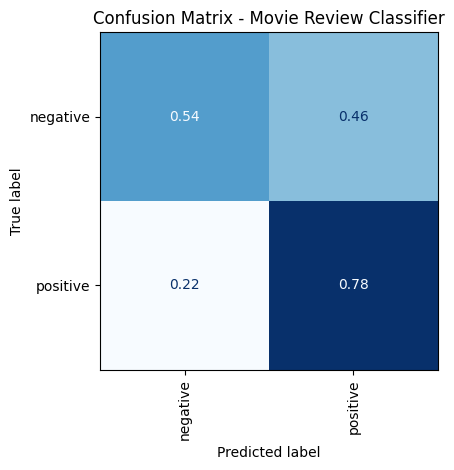

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = ConfusionMatrixDisplay.from_predictions(
    y_text_test, y_text_pred,
    display_labels=np.unique(y_text_test),
    cmap="Blues",
    normalize="true",
    xticks_rotation=90,
    values_format=".2f",
    colorbar=False
)
plt.title("Confusion Matrix - Movie Review Classifier")
plt.tight_layout()
plt.show()

Why is this important? For some problems the false positive or false negatives are not equally bad, that is, one of them is preferred.

Imagine you're building a medical system that detects when a pacient has a disease. In that case it would be preferrable to falsely predict someone needs further assessment (false positive), than sending someone home untreated (false negative).

Conversely, if we are building a spam filter, it's probably better to have some spam e-mails arrive to the mailbox (false negative) than accidentaly filter an important email (false positive).

For that reason, sometimes we aim at maximising other metrics instead of accuracy.


#### Calculating Precision and Recall 🔢

Now that we've calculated the number of true positives, false positives, and false negatives, we can calcualate **precision** and **recall** simply with the below formulae:

$$
\text{Precision} = \dfrac{TP}{TP + FP}
$$

$$
\text{Recall} = \dfrac{TP}{TP + FN}
$$


Precision, then, is higher when we have little false positives. We can think of precision as the following: out of all the predicted positives, how many actually were supposed to be positive?

Recall, on the other hand, is higher when we have little false negatives. We can then say: out of all the outputs that were supposed to be positive, how many positives were predicted?

Let's calculate both **precision** and **recall** in Python.

In [59]:
precision_text = tp_text / (tp_text + fp_text)
recall_text = tp_text / (tp_text + fn_text)
print("Precision: ", precision_text)
print("Recall: ", recall_text)

Precision:  0.628620652525035
Recall:  0.78341384863124


## F1-Score: Unifying Precision and Recall 🇫

The **F1-score** is a metric that combines **precision** and **recall** into a single value, providing a balance between them. It is especially useful when we want to account for both false positives and false negatives.

Mathematically, it is the [**harmonic mean**](https://en.wikipedia.org/wiki/Harmonic_mean) of precision and recall:

$$
F_1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}
$$

> **Did you know?** The harmonic mean is another kind of *average*, just like the **arithmetic mean** (which is the mean you are probably most familiar with!)

A high F1-score indicates that a model has both **high precision and high recall**, while a low F1-score shows that **either or both are lacking**.


In [60]:
fscore_text = 2 * (precision_text * recall_text) / (precision_text + recall_text)
print("F1-Score: ", fscore_text)

F1-Score:  0.6975327080470757


The F1-score provides a **much fairer** account for some systems than any one of precision, recall, or accuracy. 

### More Evaluation Metrics ⏩

In this section, we've explored the following concepts:

- **Fair and Unfair Metrics**
- **True and False Positives and Negatives**
- **Precision and Recall**
- **F1-Score**

#### Which Metric Should I Use? 🤔

Ultimately, the correct metric to use to evaluate a machine learning model will depend on a variety of factors, which may include:

1. **The dataset used** (size, qualities, class distribution)
2. **The learning paradigm** (unsupervised, supervised, self-supervised)
3. **Scientific conventions** (what metrics do other machine learning researchers use for this task?)
4. **Application objectives** (what questions are we trying to answer with this model?)
5. **Domain-specific requirements** (in healthcare, recall may be prioritized to avoid missing critical cases)
6. **Model interpretability** (simpler metrics may be preferred when results need to be explained to non-technical stakeholders)

### Audio classification task

Since we have now four classes, we're no longer dealing with a binary classifier.

In this case, we should treat each class' classification as a separate task, regarding if a sample was predicted correctly or incorrectly. Each case is a one-vs-rest binary problem.

Then we can analyse them separately or perform an average.

FURTHER EXPLAIN AND CALCULATE CASES

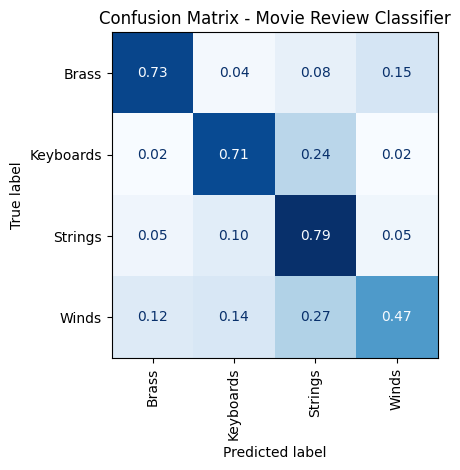

In [63]:
cm = ConfusionMatrixDisplay.from_predictions(
    y_audio_test, y_audio_pred,
    display_labels=np.unique(y_audio_test),
    cmap="Blues",
    normalize="true",
    xticks_rotation=90,
    values_format=".2f",
    colorbar=False
)
plt.title("Confusion Matrix - Movie Review Classifier")
plt.tight_layout()
plt.show()

ADD ANALYSIS

ADD AVERAGE

### Image classification task

What about our binary images classifier? Let's think of "automobile" as positive and "airplane" as negative.

In [ ]:
tp_images = np.sum((y_images_test == "automobile") & (y_images_pred == "automobile"))
tn_images = np.sum((y_images_test == "airplane") & (y_images_pred == "airplane"))
fp_images = np.sum((y_images_test == "airplane") & (y_images_pred == "automobile"))
fn_images = np.sum((y_images_test == "automobile") & (y_images_pred == "airplane"))
print(f"True Positives: {tp_images}")
print(f"True Negatives: {tn_images}")
print(f"False Positives: {fp_images}")
print(f"False Negatives: {fn_images}")

True Positives: 911
True Negatives: 802
False Positives: 198
False Negatives: 89


Our model tends to think some airplanes are automobiles!

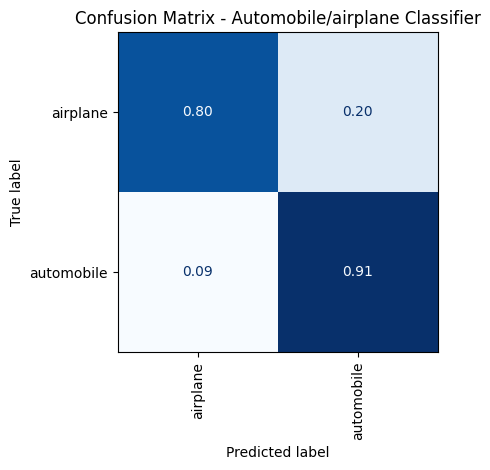

In [ ]:
cm = ConfusionMatrixDisplay.from_predictions(
    y_images_test, y_images_pred,
    display_labels=np.unique(y_images_test),
    cmap="Blues",
    normalize="true",
    xticks_rotation=90,
    values_format=".2f",
    colorbar=False
)
plt.title("Confusion Matrix - Automobile/airplane Classifier")
plt.tight_layout()
plt.show()

In [61]:
precision_images = tp_images / (tp_images + fp_images)
recall_images = tp_images / (tp_images + fn_images)
print("Precision: ", precision_images)
print("Recall: ", recall_images)

Precision:  0.8214607754733995
Recall:  0.911


In [62]:
fscore_images = 2 * (precision_images * recall_images) / (precision_images + recall_images)
print("F1-Score: ", fscore_images)

F1-Score:  0.8639165481270745
